In [1]:
#  IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [7]:
# LOAD DATASET
df = pd.read_excel(r"C:\Users\CDIT BIDAR\DS_P661\bankruptcy-prevention.xlsx")
df

,industrial_risk; management_risk; financial_flexibility;,credibility;,competitiveness;,operating_risk;,class
0,0.5;1;0;0;0;0.5;bankruptcy,NaN,NaN,NaN,NaN
1,0;1;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
2,1;0;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
3,0.5;0;0;0.5;0;1;bankruptcy,NaN,NaN,NaN,NaN
4,1;1;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
...,...,...,...,...,...
245,0;1;1;1;1;1;non-bankruptcy,NaN,NaN,NaN,NaN
246,1;1;0.5;1;1;0;non-bankruptcy,NaN,NaN,NaN,NaN
247,0;1;1;0.5;0.5;0;non-bankruptcy,NaN,NaN,NaN,NaN
248,1;0;0.5;1;0.5;0;non-bankruptcy,NaN,NaN,NaN,NaN


In [8]:
df.head()

,industrial_risk; management_risk; financial_flexibility;,credibility;,competitiveness;,operating_risk;,class
0,0.5;1;0;0;0;0.5;bankruptcy,NaN,NaN,NaN,NaN
1,0;1;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
2,1;0;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN
3,0.5;0;0;0.5;0;1;bankruptcy,NaN,NaN,NaN,NaN
4,1;1;0;0;0;1;bankruptcy,NaN,NaN,NaN,NaN


In [9]:
df.tail()

,industrial_risk; management_risk; financial_flexibility;,credibility;,competitiveness;,operating_risk;,class
245,0;1;1;1;1;1;non-bankruptcy,NaN,NaN,NaN,NaN
246,1;1;0.5;1;1;0;non-bankruptcy,NaN,NaN,NaN,NaN
247,0;1;1;0.5;0.5;0;non-bankruptcy,NaN,NaN,NaN,NaN
248,1;0;0.5;1;0.5;0;non-bankruptcy,NaN,NaN,NaN,NaN
249,1;0;0.5;0.5;1;1;non-bankruptcy,NaN,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   industrial_risk; management_risk; financial_flexibility;  250 non-null    object 
 1   credibility;                                              0 non-null      float64
 2   competitiveness;                                          0 non-null      float64
 3   operating_risk;                                           0 non-null      float64
 4   class                                                     0 non-null      float64
dtypes: float64(4), object(1)
memory usage: 9.9+ KB


In [11]:
df.describe()

,credibility;,competitiveness;,operating_risk;,class
count,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN


In [12]:
df.dtypes

industrial_risk; management_risk; financial_flexibility;     object
credibility;                                                float64
competitiveness;                                            float64
operating_risk;                                             float64
class                                                       float64
dtype: object

In [13]:
df.shape

(250, 5)

In [14]:
df.columns

Index(['industrial_risk; management_risk; financial_flexibility;',
       'credibility;', 'competitiveness;', 'operating_risk;', 'class'],
      dtype='object')

In [15]:
df.isnull().sum()

industrial_risk; management_risk; financial_flexibility;      0
credibility;                                                250
competitiveness;                                            250
operating_risk;                                             250
class                                                       250
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(147)

In [17]:
# Step 1: split column
df_split = df.iloc[:, 0].fillna('').astype(str).str.split(';', expand=True)

In [18]:
# Step 2: assign column names
df_split.columns = [
    'industrial_risk',
    'management_risk',
    'financial_flexibility',
    'credibility',
    'competitiveness',
    'operating_risk',
    'class'
]

# Step 3: replace original df
df = df_split

# Step 4: convert to numeric
for col in df.columns[:-1]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 5: encode target
df['class'] = df['class'].map({
    'bankruptcy': 1,
    'non-bankruptcy': 0
})

In [19]:
df_split

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,1
1,0.0,1.0,0.0,0.0,0.0,1.0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,1
3,0.5,0.0,0.0,0.5,0.0,1.0,1
4,1.0,1.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,0
246,1.0,1.0,0.5,1.0,1.0,0.0,0
247,0.0,1.0,1.0,0.5,0.5,0.0,0
248,1.0,0.0,0.5,1.0,0.5,0.0,0


In [20]:
df_split.isnull().sum()

industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

In [21]:
df_split.duplicated().sum()

np.int64(147)

In [22]:
df_split

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,1
1,0.0,1.0,0.0,0.0,0.0,1.0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,1
3,0.5,0.0,0.0,0.5,0.0,1.0,1
4,1.0,1.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...
245,0.0,1.0,1.0,1.0,1.0,1.0,0
246,1.0,1.0,0.5,1.0,1.0,0.0,0
247,0.0,1.0,1.0,0.5,0.5,0.0,0
248,1.0,0.0,0.5,1.0,0.5,0.0,0


In [23]:
df_split.drop_duplicates(inplace=True)

In [24]:
df_split.duplicated().sum()

np.int64(0)

In [25]:
df_split

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,1
1,0.0,1.0,0.0,0.0,0.0,1.0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,1
3,0.5,0.0,0.0,0.5,0.0,1.0,1
4,1.0,1.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...
185,0.0,0.5,0.0,0.5,1.0,0.5,0
187,0.0,0.5,0.5,0.5,1.0,0.5,0
190,0.0,0.5,0.5,0.0,1.0,0.0,0
192,0.5,1.0,0.0,0.0,1.0,0.0,0


In [26]:
# Outlier Detection
# Function to detect outliers using IQR
def detect_outliers(df, cols):
    outlier_count = {}

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count[col] = len(outliers)

    return outlier_count


num_cols = df.columns[:-1]  # excluding target
print("Outliers count:\n", detect_outliers(df, num_cols))

Outliers count:
 {'industrial_risk': 0, 'management_risk': 0, 'financial_flexibility': 0, 'credibility': 0, 'competitiveness': 0, 'operating_risk': 0}


In [27]:
# DATA VISUALIZATION

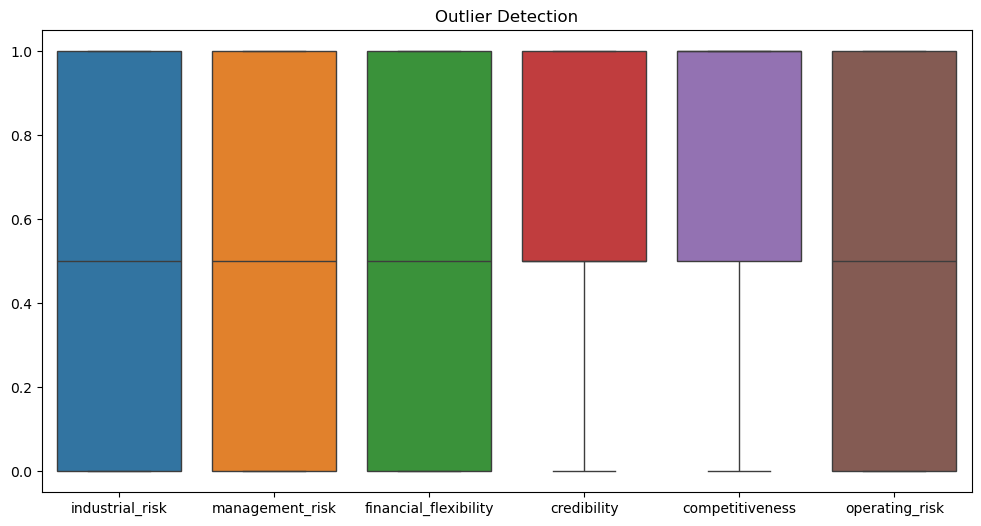

In [28]:
#Outlier Detection

plt.figure(figsize=(12,6))
sns.boxplot(data=df.iloc[:,:-1])
plt.title("Outlier Detection")
plt.show()

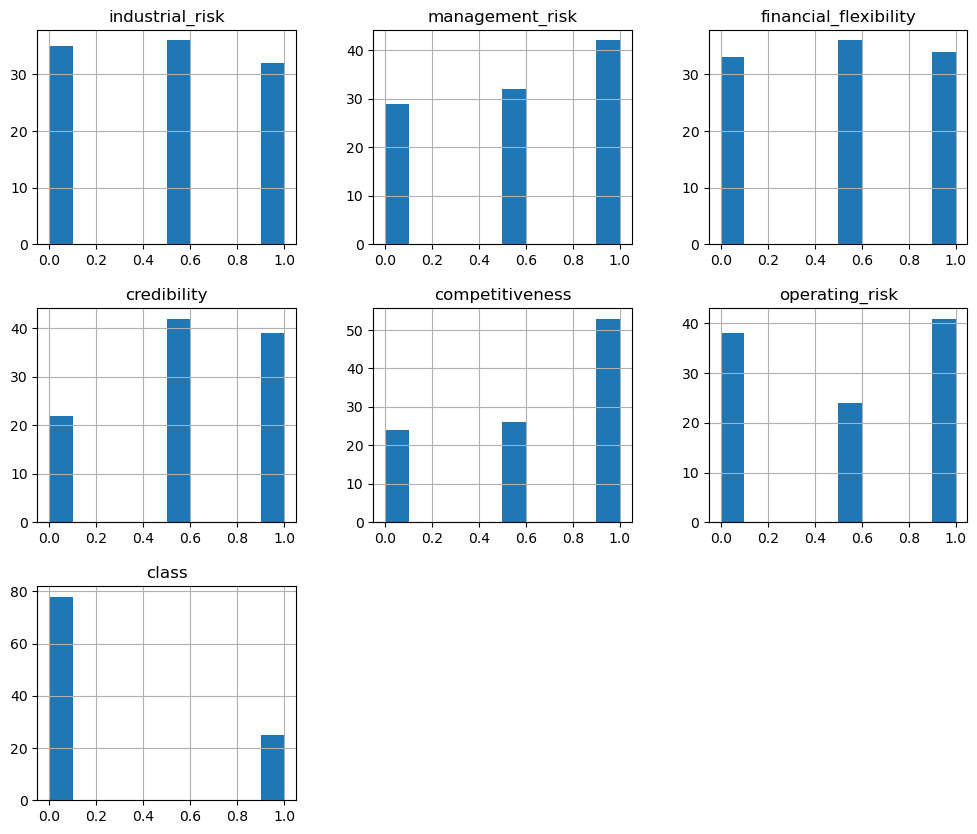

In [29]:
# Feature Distribution

df.hist(figsize=(12,10))
plt.show()

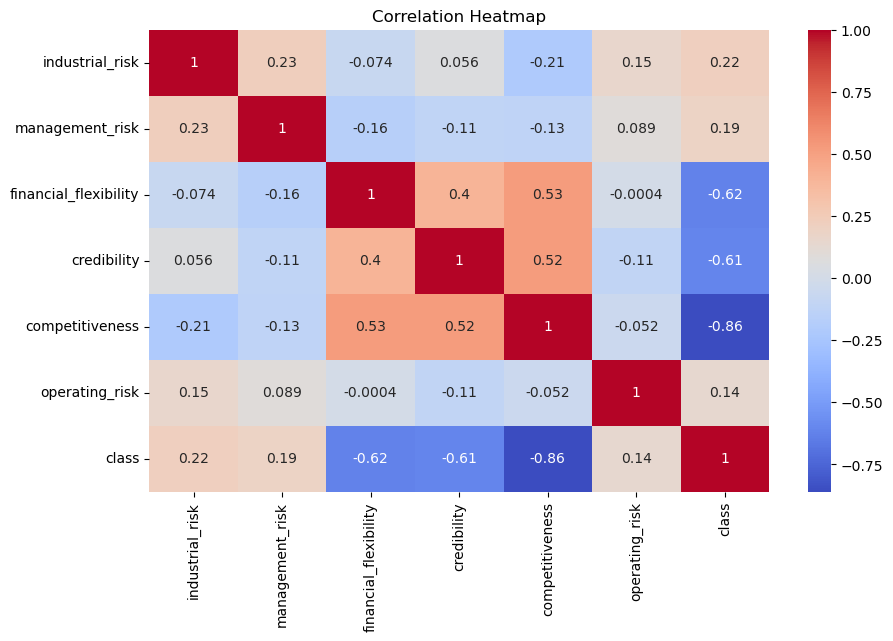

In [30]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

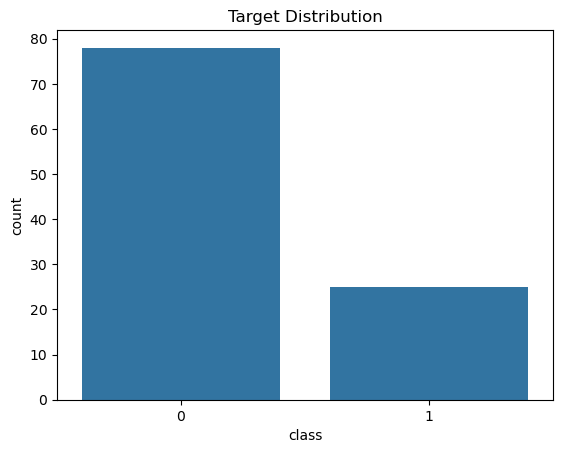

In [31]:
# Target Variable Analysis

sns.countplot(x='class', data=df)
plt.title("Target Distribution")
plt.show()

In [32]:
# Feature Engineering

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('class', axis=1)
y = df['class']

X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)

In [33]:
df

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,1
1,0.0,1.0,0.0,0.0,0.0,1.0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,1
3,0.5,0.0,0.0,0.5,0.0,1.0,1
4,1.0,1.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...
185,0.0,0.5,0.0,0.5,1.0,0.5,0
187,0.0,0.5,0.5,0.5,1.0,0.5,0
190,0.0,0.5,0.5,0.0,1.0,0.0,0
192,0.5,1.0,0.0,0.0,1.0,0.0,0


In [34]:
df_split

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,1
1,0.0,1.0,0.0,0.0,0.0,1.0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,1
3,0.5,0.0,0.0,0.5,0.0,1.0,1
4,1.0,1.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...
185,0.0,0.5,0.0,0.5,1.0,0.5,0
187,0.0,0.5,0.5,0.5,1.0,0.5,0
190,0.0,0.5,0.5,0.0,1.0,0.0,0
192,0.5,1.0,0.0,0.0,1.0,0.0,0


In [35]:
# Example: risk score (custom feature)
df['risk_score'] = (
    df['industrial_risk'] +
    df['management_risk'] +
    df['financial_flexibility']
) / 3

In [36]:
df['risk_score']

0      0.500000
1      0.333333
2      0.333333
3      0.166667
4      0.666667
         ...   
185    0.166667
187    0.333333
190    0.333333
192    0.500000
194    0.500000
Name: risk_score, Length: 103, dtype: float64

In [37]:
# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
X_new = selector.fit_transform(X, y)

In [38]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
# Model Building

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Decision Tree Accuracy: 0.9523809523809523


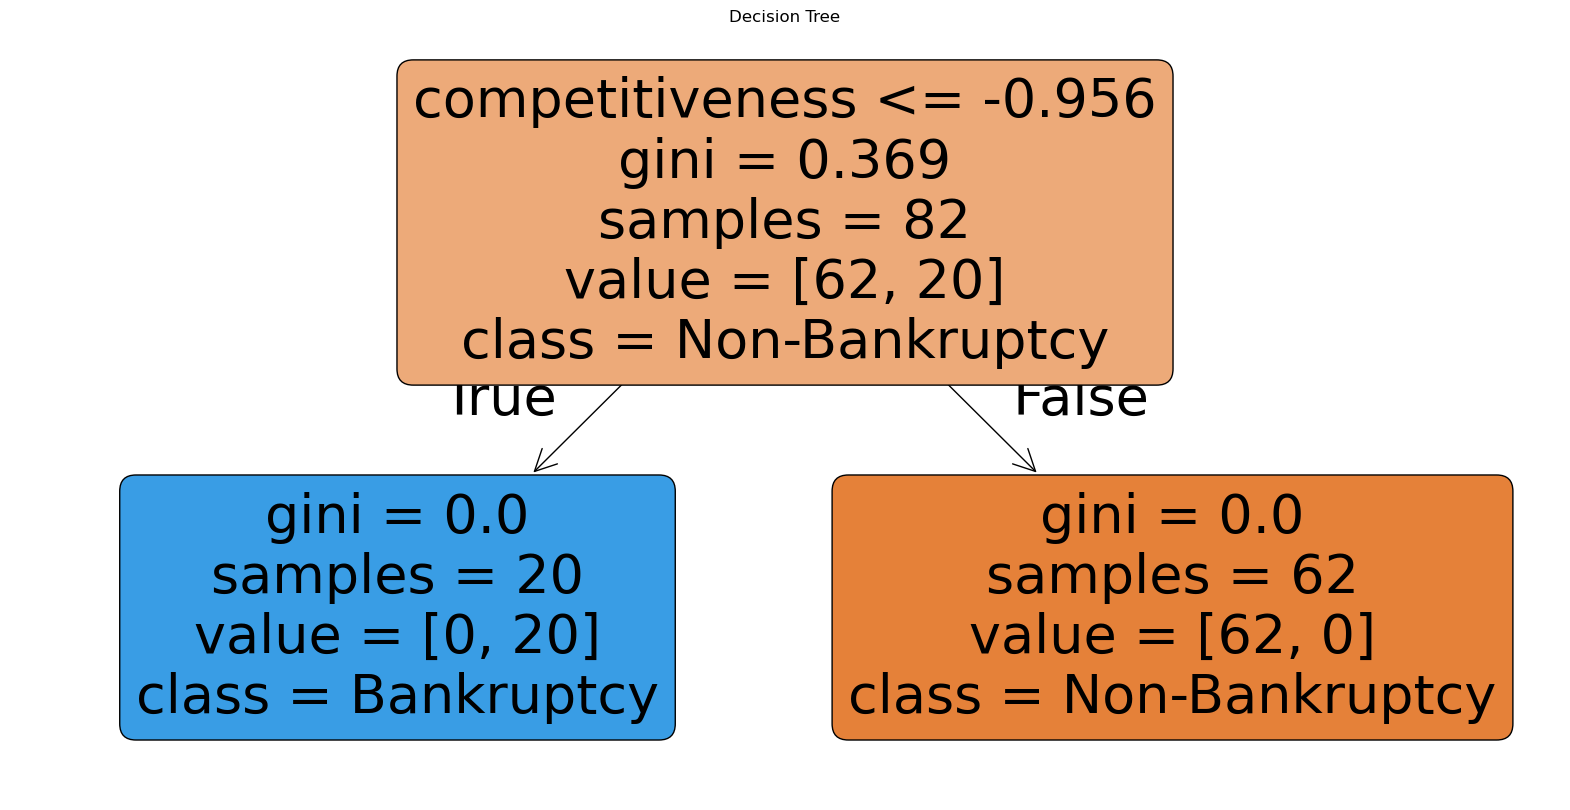

In [40]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, rounded=True, feature_names=list(X.columns),
          class_names=['Non-Bankruptcy','Bankruptcy'], max_depth=3)
plt.title("Decision Tree")
plt.show()


Random Forest Accuracy: 0.9523809523809523


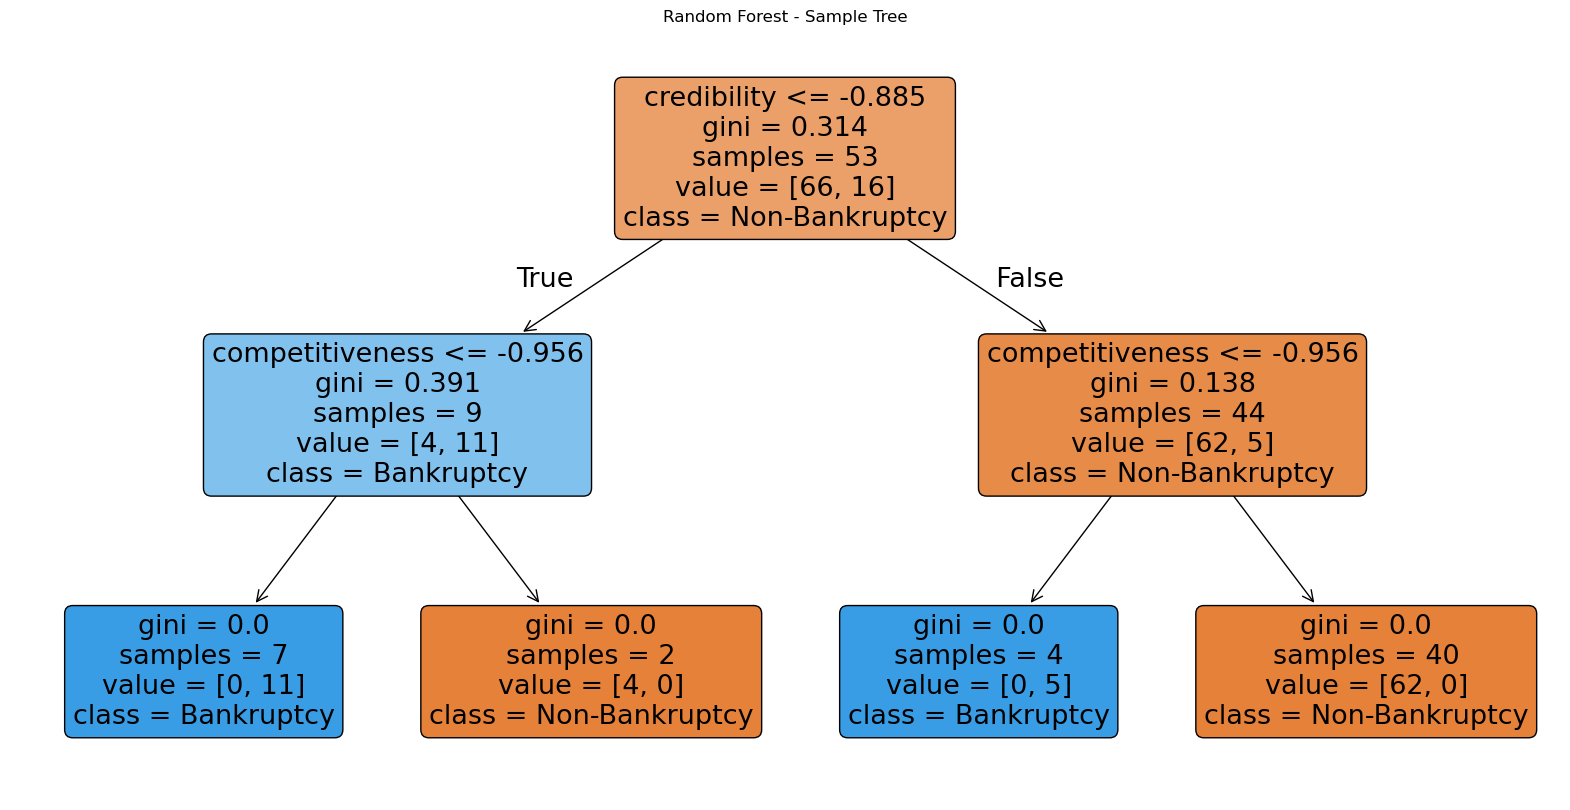

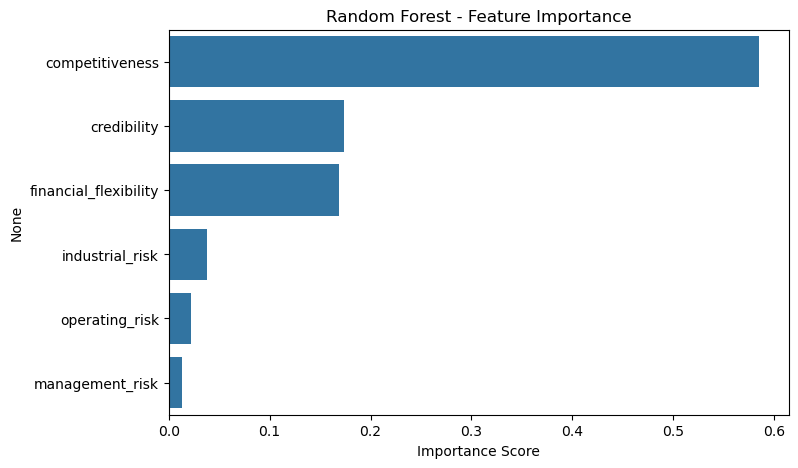

In [41]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

# Show one tree from the forest
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], filled=True, rounded=True,
          feature_names=list(X.columns),
          class_names=['Non-Bankruptcy','Bankruptcy'], max_depth=3)
plt.title("Random Forest - Sample Tree")
plt.show()

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance Score")
plt.show()


Gradient Boosting Accuracy: 0.9523809523809523


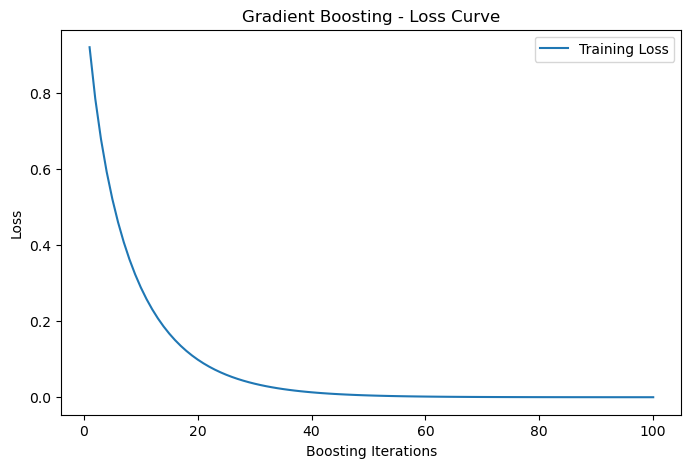

In [42]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

# Training Deviance (Loss Curve)
plt.figure(figsize=(8,5))
plt.plot(np.arange(gb.n_estimators_) + 1, gb.train_score_, label='Training Loss')
plt.xlabel('Boosting Iterations')
plt.ylabel('Loss')
plt.title('Gradient Boosting - Loss Curve')
plt.legend()
plt.show()


In [43]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV


In [44]:
# Decision Tree - GridSearchCV

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train, y_train)

print("Best Params:", gs_dt.best_params_)
print("Best CV Score:", gs_dt.best_score_)


Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 1.0


In [45]:
# Random Forest - GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train, y_train)

print("Best Params:", gs_rf.best_params_)
print("Best CV Score:", gs_rf.best_score_)


Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 1.0


In [55]:
# Gradient Boosting - GridSearchCV

param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gs_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
gs_gb.fit(X_train, y_train)

print("Best Params:", gs_gb.best_params_)
print("Best CV Score:", gs_gb.best_score_)


Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 1.0


In [56]:
# Model Evaluation


Decision Tree
Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.80      0.89         5

    accuracy                           0.95        21
   macro avg       0.97      0.90      0.93        21
weighted avg       0.96      0.95      0.95        21



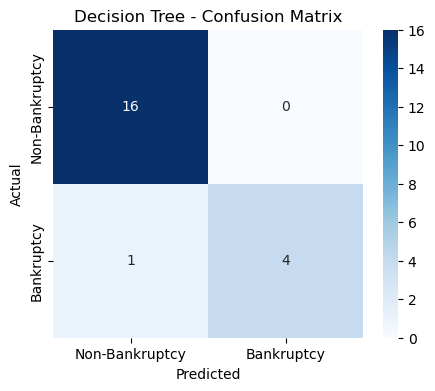

In [57]:
# Decision Tree - Evaluation

best_dt = gs_dt.best_estimator_
dt_pred = best_dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Bankruptcy','Bankruptcy'],
            yticklabels=['Non-Bankruptcy','Bankruptcy'])
plt.title("Decision Tree - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


Random Forest
Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.80      0.89         5

    accuracy                           0.95        21
   macro avg       0.97      0.90      0.93        21
weighted avg       0.96      0.95      0.95        21



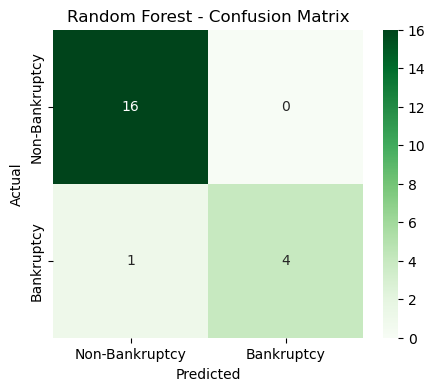

In [58]:
# Random Forest - Evaluation

best_rf = gs_rf.best_estimator_
rf_pred = best_rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Bankruptcy','Bankruptcy'],
            yticklabels=['Non-Bankruptcy','Bankruptcy'])
plt.title("Random Forest - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


Gradient Boosting
Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        16
           1       1.00      0.80      0.89         5

    accuracy                           0.95        21
   macro avg       0.97      0.90      0.93        21
weighted avg       0.96      0.95      0.95        21



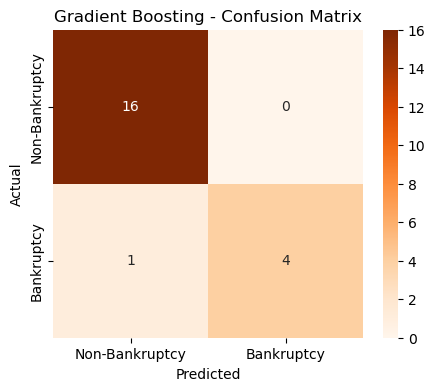

In [59]:
# Gradient Boosting - Evaluation

best_gb = gs_gb.best_estimator_
gb_pred = best_gb.predict(X_test)

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Bankruptcy','Bankruptcy'],
            yticklabels=['Non-Bankruptcy','Bankruptcy'])
plt.title("Gradient Boosting - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


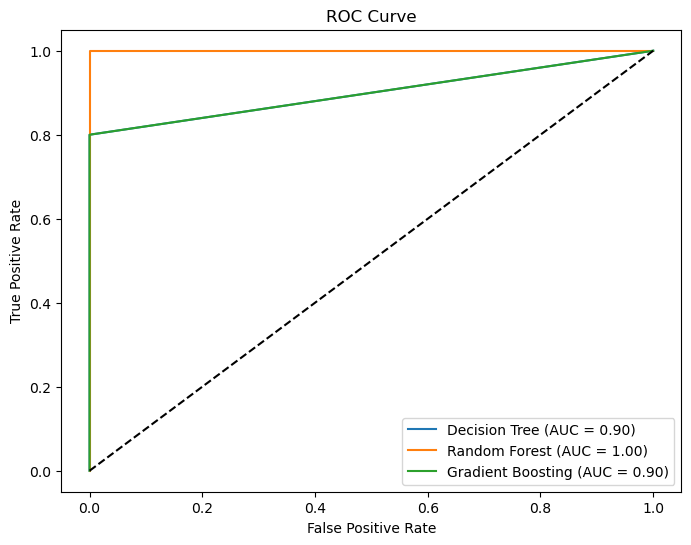

In [60]:
# ROC Curve - All Models

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for model, name, pred in [
    (best_dt, 'Decision Tree', dt_pred),
    (best_rf, 'Random Forest', rf_pred),
    (best_gb, 'Gradient Boosting', gb_pred)
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


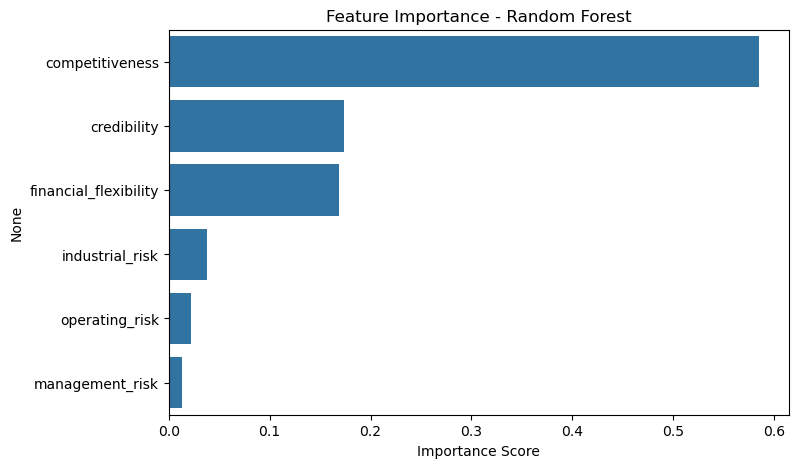

In [61]:
# Feature Importance - Random Forest

feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()


               Model  Accuracy
0      Decision Tree  0.952381
1      Random Forest  0.952381
2  Gradient Boosting  0.952381


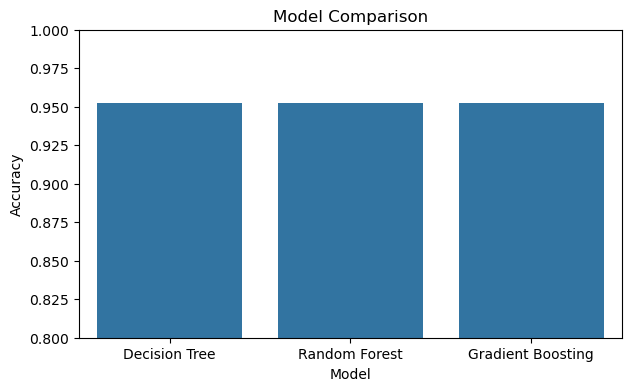

In [62]:
# Model Comparison

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(results)

plt.figure(figsize=(7,4))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Comparison")
plt.ylim(0.8, 1.0)
plt.show()


In [54]:
# Save Best Model

best_model = gs_rf.best_estimator_
joblib.dump(best_model, 'bankruptcy_model.pkl')
print("Model saved")


Model saved
